In [1]:
#Task 1 — Vectorize It (NumPy)

import numpy as np
prices = [10, 25, 35, 40, 50, 55, 60, 65, 70, 75,
          80, 85, 90, 95, 100, 110, 120, 130, 150, 200]

# 1. Loop-based version: apply 8% tax
taxed_loop = []
for price in prices:
    taxed_loop.append(price * 1.08)
print("Loop-based:", taxed_loop)

# 2. NumPy vectorized version
prices_array = np.array(prices)
taxed_numpy = prices_array * 1.08
print("Vectorized:", taxed_numpy)
# Check both results are identical
print("Results are identical:", np.allclose(taxed_loop, taxed_numpy))

# 3. Boolean masking: select taxed prices above 50
above_50 = taxed_numpy[taxed_numpy > 50]
print("Taxed prices above 50:", above_50)

# 4. Small 2D array
data = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])
# Row sums
row_sums = data.sum(axis=1)
# Column sums
column_sums = data.sum(axis=0)
print("Row sums:", row_sums)
print("Column sums:", column_sums)

Loop-based: [10.8, 27.0, 37.800000000000004, 43.2, 54.0, 59.400000000000006, 64.80000000000001, 70.2, 75.60000000000001, 81.0, 86.4, 91.80000000000001, 97.2, 102.60000000000001, 108.0, 118.80000000000001, 129.60000000000002, 140.4, 162.0, 216.0]
Vectorized: [ 10.8  27.   37.8  43.2  54.   59.4  64.8  70.2  75.6  81.   86.4  91.8
  97.2 102.6 108.  118.8 129.6 140.4 162.  216. ]
Results are identical: True
Taxed prices above 50: [ 54.   59.4  64.8  70.2  75.6  81.   86.4  91.8  97.2 102.6 108.  118.8
 129.6 140.4 162.  216. ]
Row sums: [100 260 420]
Column sums: [150 180 210 240]


In [3]:
#Task 2 — Load & Explore

import pandas as pd
employees = pd.DataFrame({
    "name": [
        "Alice", "Bob", "Charlie", "David", "Emma",
        "Frank", "Grace", "Henry", "Isha", "Jack",
        "Kiran", "Liam", "Maya", "Noah", "Olivia"
    ],
    "department": [
        "IT", "HR", "Finance", "IT", "HR",
        "Finance", "IT", "Sales", "Sales", "Finance",
        "IT", "HR", "Sales", "Finance", "IT"
    ],
    "salary": [
        60000, 45000, 55000, 70000, 48000,
        58000, 75000, 50000, 52000, 62000,
        80000, 47000, 56000, 65000, 85000
    ],
    "years_experience": [
        3, 2, 4, 5, 3,
        5, 7, 2, 3, 6,
        8, 3, 4, 6, 9
    ]
})

# Save to CSV
employees.to_csv("employees.csv", index=False)

# 1. Read CSV
df = pd.read_csv("employees.csv")
print(df)

# Display information
print("\nDataFrame Info:")
print(df.info())

# Statistical description
print("\nDataFrame Description:")
print(df.describe())

# 2. Filter IT department using boolean indexing
it_boolean = df[df["department"] == "IT"]
print("\nIT employees using Boolean indexing:")
print(it_boolean)

# Filter IT department using query()
it_query = df.query("department == 'IT'")
print("\nIT employees using query():")
print(it_query)

# Check both methods return the same rows
print("\nBoth filtering methods same:",
      it_boolean.reset_index(drop=True).equals(
          it_query.reset_index(drop=True)
      ))

# 3. Group by department
department_summary = (
    df.groupby("department")
      .agg(
          average_salary=("salary", "mean"),
          headcount=("name", "count")
      )
)
print("\nDepartment Summary:")
print(department_summary)

# 4. Sort by average salary descending
department_summary = department_summary.sort_values(
    "average_salary",
    ascending=False
)
print("\nSorted Department Summary:")
print(department_summary)

       name department  salary  years_experience
0     Alice         IT   60000                 3
1       Bob         HR   45000                 2
2   Charlie    Finance   55000                 4
3     David         IT   70000                 5
4      Emma         HR   48000                 3
5     Frank    Finance   58000                 5
6     Grace         IT   75000                 7
7     Henry      Sales   50000                 2
8      Isha      Sales   52000                 3
9      Jack    Finance   62000                 6
10    Kiran         IT   80000                 8
11     Liam         HR   47000                 3
12     Maya      Sales   56000                 4
13     Noah    Finance   65000                 6
14   Olivia         IT   85000                 9

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   

In [4]:
#Task 3 — Join the Data & Missing Values

import numpy as np
import pandas as pd
departments = pd.DataFrame({
    "department": ["IT", "HR", "Finance", "Sales"],
    "department_budget": [500000, 250000, 400000, 300000]
})
print("Departments:")
print(departments)

# 1. Inner join
inner_join = pd.merge(
    df,
    departments,
    on="department",
    how="inner"
)
print("\nInner Join:")
print(inner_join)

# 2. Add employee whose department does not exist
new_employee = pd.DataFrame({
    "name": ["Peter"],
    "department": ["Marketing"],
    "salary": [60000],
    "years_experience": [4]
})
df_with_extra = pd.concat(
    [df, new_employee],
    ignore_index=True
)

# Left join
left_join = pd.merge(
    df_with_extra,
    departments,
    on="department",
    how="left"
)
print("\nLeft Join:")
print(left_join)

# 3. Introduce two missing values
df_missing = df.copy()
df_missing.loc[2, "salary"] = np.nan
df_missing.loc[7, "years_experience"] = np.nan
print("\nData with missing values:")
print(df_missing)

# Detect missing values
print("\nMissing values:")
print(df_missing.isna().sum())

# 4. Fill missing values
salary_mean = df_missing["salary"].mean()
df_missing["salary"] = df_missing["salary"].fillna(salary_mean)
experience_median = df_missing["years_experience"].median()
df_missing["years_experience"] = df_missing[
    "years_experience"
].fillna(experience_median)
print("\nData after handling missing values:")
print(df_missing)
print("\nMissing values after handling:")
print(df_missing.isna().sum())

Departments:
  department  department_budget
0         IT             500000
1         HR             250000
2    Finance             400000
3      Sales             300000

Inner Join:
       name department  salary  years_experience  department_budget
0     Alice         IT   60000                 3             500000
1       Bob         HR   45000                 2             250000
2   Charlie    Finance   55000                 4             400000
3     David         IT   70000                 5             500000
4      Emma         HR   48000                 3             250000
5     Frank    Finance   58000                 5             400000
6     Grace         IT   75000                 7             500000
7     Henry      Sales   50000                 2             300000
8      Isha      Sales   52000                 3             300000
9      Jack    Finance   62000                 6             400000
10    Kiran         IT   80000                 8             50000

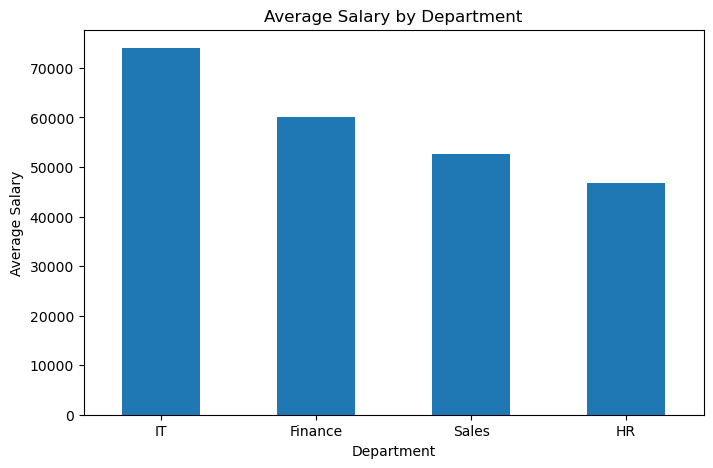

In [8]:
#Task 4 — Tell a Story with Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar Chart

average_salary = (
    df.groupby("department")["salary"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8, 5))
average_salary.plot(kind="bar")
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.show()

# "Which department has the highest or lowest average salary?"

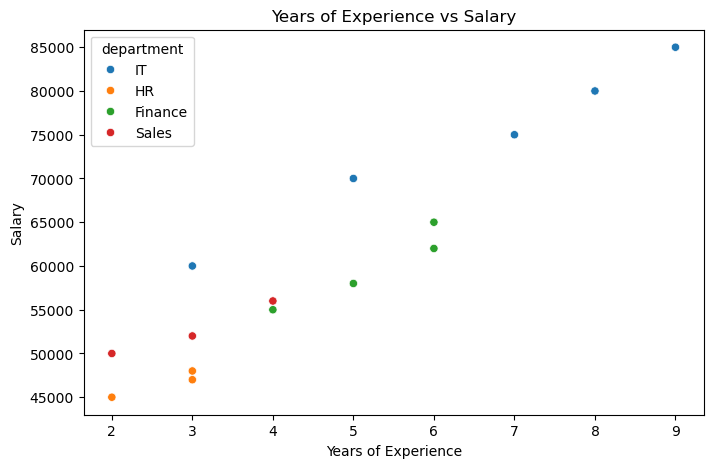

In [9]:
# 2. Scatter Plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary",
    hue="department"
)
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# "Is there a relationship between years of experience and salary?"

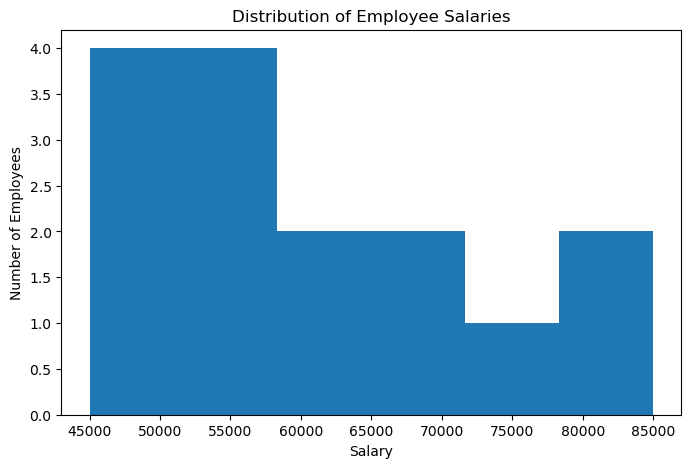

In [10]:
# 3. Histogram

plt.figure(figsize=(8, 5))
plt.hist(df["salary"], bins=6)
plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

# "How are employee salaries distributed?"

In [ ]:
#Task 5 — Consolidation Reflection

1.Java habits I had to adjust:

OOP: In Java, I am used to explicitly defining classes, types, and methods. In Python, I learned that the syntax is simpler and features like dunder methods are used for special behavior.
FastAPI/Testing: In Java, I am more used to traditional frameworks and explicit type definitions. With FastAPI and Pydantic, I learned that request validation and API definitions can be handled more directly using Python models.
Pandas/NumPy: In Java, I would normally use loops and collections for data processing. In NumPy and Pandas, I learned to use vectorized operations, DataFrames, filtering, and aggregation instead.

2. Skill I expect to use again:
I learned NumPy vectorized operations, which allow us to process many values without writing explicit loops. I expect this to be useful in upcoming ML and DL modules because numerical data and arrays are used heavily when preparing data and working with models.

3. Least confident topic:
I feel least confident about Pandas merging and handling missing data. I will practice more examples using merge(), isna(), fillna(), and different join types before the readiness assessment.

In [16]:
#Task 6 — Readiness Self-Check

#1. Python class with constructor and dunder method

class Employee:
    def __init__(self, name, salary):
        self.name = name
        self.salary = salary
    def __str__(self):
        return f"{self.name} - {self.salary}"
employee = Employee("Alice", 60000)
print(employee)

#2. Pandas groupby().agg()

import pandas as pd
df = pd.DataFrame({
    "department": ["IT", "IT", "HR", "HR"],
    "salary": [60000, 70000, 45000, 50000]
})
summary = (
    df.groupby("department")
      .agg(
          average_salary=("salary", "mean"),
          headcount=("salary", "count")
      )
)
print(summary)

Alice - 60000
            average_salary  headcount
department                           
HR                 47500.0          2
IT                 65000.0          2
